### Importing all required libraries

In [ ]:
# !pip uninstall flwr -y
# !pip install flwr==1.7.0

In [2]:
import os
import glob
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, BatchNormalization, Dropout, Concatenate,
    GlobalAveragePooling2D, Conv2D, MaxPooling2D, Flatten
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.utils import Sequence
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Federated Learning Framework
import flwr as fl

warnings.filterwarnings("ignore")

print("All libraries imported successfully")
print("Flower version:", fl.__version__)
print("TensorFlow version:", tf.__version__)

### Kaggle setup

In [3]:
if not os.path.exists('/root/.kaggle'):
    os.makedirs('/root/.kaggle')

!mv kaggle.json /root/.kaggle/ 2>/dev/null || true
!chmod 600 /root/.kaggle/kaggle.json 2>/dev/null || true

### Extracting dataset from kaggle

In [4]:
!kaggle datasets download -d andrewmvd/leukemia-classification -p /content/

with zipfile.ZipFile('/content/leukemia-classification.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/B_Raw/')

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/leukemia-classification
License(s): other
100% 867M/867M [00:40<00:00, 22.3MB/s]



### Structuring folder

In [5]:
base_path = '/content/Institution_Beta'
shutil.rmtree(base_path, ignore_errors=True)
os.makedirs(f'{base_path}/Healthy', exist_ok=True)
os.makedirs(f'{base_path}/Leukemia', exist_ok=True)

In [6]:
physical_map = {}

for i, p in enumerate(glob.glob('/content/B_Raw/**/hem/*.*', recursive=True)):
    orig_name = os.path.basename(p)
    new_path = f'{base_path}/Healthy/B_H_{i}.bmp'
    shutil.copy(p, new_path)
    physical_map[orig_name] = new_path

for i, p in enumerate(glob.glob('/content/B_Raw/**/all/*.*', recursive=True)):
    orig_name = os.path.basename(p)
    new_path = f'{base_path}/Leukemia/B_L_{i}.bmp'
    shutil.copy(p, new_path)
    physical_map[orig_name] = new_path

print(f"Images Moved. Healthy: {len(os.listdir(base_path+'/Healthy'))}, Leukemia: {len(os.listdir(base_path+'/Leukemia'))}")

Images Moved. Healthy: 3389, Leukemia: 7272


### Importing Clinical Data

In [ ]:
df_b = pd.read_csv('/content/hospital_B_clinical.csv')

In [ ]:
healthy_images = sorted(glob.glob('/content/Institution_Beta/Healthy/*.bmp'))
leukemia_images = sorted(glob.glob('/content/Institution_Beta/Leukemia/*.bmp'))

np.random.shuffle(healthy_images)
np.random.shuffle(leukemia_images)

df_b['image_path'] = None

for label, image_pool in [(0, healthy_images), (1, leukemia_images)]:
    patients = df_b[df_b['Diagnosis'] == label]['Patient_ID'].unique()
    idx = 0

    for p in patients:
        patient_idx = df_b[(df_b['Patient_ID'] == p) & (df_b['Diagnosis'] == label)].index

        for i in range(len(patient_idx)):
            if idx >= len(image_pool):
                break
            df_b.loc[patient_idx[i], 'image_path'] = image_pool[idx]
            idx += 1

df_b = df_b.dropna(subset=['image_path']).reset_index(drop=True)

In [ ]:
features = [
    'WBC_count', 'LDH_level', 'Hemoglobin', 'Platelet_count',
    'RBC_count', 'Hematocrit', 'Lymphocyte_percentage',
    'Neutrophil_percentage', 'Uric_acid'
]

### Spliting data into train and test

In [ ]:
unique_patients = df_b['Patient_ID'].unique()

train_ids, temp_ids = train_test_split(
    unique_patients, test_size=0.3, random_state=42
)

val_ids, test_ids = train_test_split(
    temp_ids, test_size=0.5, random_state=42
)

train_df = df_b[df_b['Patient_ID'].isin(train_ids)].reset_index(drop=True)
val_df   = df_b[df_b['Patient_ID'].isin(val_ids)].reset_index(drop=True)
test_df  = df_b[df_b['Patient_ID'].isin(test_ids)].reset_index(drop=True)

Institution Beta Ready: 7462 train rows, 1600 test rows, 1599 val rows.


In [ ]:
print("Train-Test overlap:",
      len(set(train_df['Patient_ID']) & set(test_df['Patient_ID'])))

### Scaling tabular data

In [ ]:
scaler_b = StandardScaler()

train_df[features] = scaler_b.fit_transform(train_df[features])
val_df[features]   = scaler_b.transform(val_df[features])
test_df[features]  = scaler_b.transform(test_df[features])

### Data Agumentation

In [ ]:
aug = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

### THE MULTIMODAL DATA ENGINE

In [ ]:
class LeukemiaDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, dataframe, batch_size=32, target_size=(224, 224), shuffle=True, is_training=True, mixup_alpha=0.2):
        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.is_training = is_training
        self.mixup_alpha = mixup_alpha
        self.features = [
            'WBC_count', 'LDH_level', 'Hemoglobin', 'Platelet_count',
            'RBC_count', 'Hematocrit', 'Lymphocyte_percentage',
            'Neutrophil_percentage', 'Uric_acid'
        ]

        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

    def __getitem__(self, index):
        batch = self.df.iloc[index * self.batch_size : (index + 1) * self.batch_size]

        images = []
        for p in batch['image_path']:
            img = img_to_array(load_img(p, target_size=self.target_size)) / 255.0
            if self.is_training:
                img = aug.random_transform(img)
            images.append(img)
        X_img = np.array(images)

        X_tab = batch[self.features].values.astype(np.float32)
        y = batch['Diagnosis'].values.astype(np.float32)

        return (X_img, X_tab), y

In [ ]:
train_gen = LeukemiaDataGenerator(train_df, is_training=True,  mixup_alpha=0.2)
val_gen   = LeukemiaDataGenerator(val_df,   shuffle=False, is_training=False)
test_gen  = LeukemiaDataGenerator(test_df,  shuffle=False, is_training=False)

### THE DUAL-INPUT ARCHITECTURE

In [ ]:
def build_local_model():

    # --- IMAGE BRANCH ---
    img_input = Input(shape=(224, 224, 3), name="image_input")

    # Block 1
    x = Conv2D(16, (3, 3), activation='relu', padding='same',kernel_regularizer=l2(1e-4))(img_input)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.20)(x)

    # Block 2
    x = Conv2D(32, (3, 3), activation='relu', padding='same',kernel_regularizer=l2(1e-4))(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    x = GlobalAveragePooling2D()(x)
    img_features = Dense(32, activation='relu',kernel_regularizer=l2(1e-4))(x)

    # --- CLINICAL BRANCH ---
    tab_input = Input(shape=(10,), name="clinical_input")
    t = Dense(16, activation='relu', kernel_regularizer=l2(1e-4))(tab_input)
    t = Dropout(0.30)(t)
    tab_features = Dense(8, activation='relu', kernel_regularizer=l2(1e-4))(t)

    # --- FUSION ---
    merged = Concatenate()([img_features, tab_features])
    z = Dense(16, activation='relu', kernel_regularizer=l2(1e-4))(merged)
    z = Dropout(0.35)(z)

    output = Dense(1, activation='sigmoid', name="diagnosis")(z)

    model = Model(inputs=[img_input, tab_input], outputs=output)

    model.compile(
        optimizer=Adam(0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
local_model = build_local_model()
local_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        448 │ image_input[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 112, 112,  │          0 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │      4,640 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_input      │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 56, 56,    │          0 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        176 │ clinical_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ dropout_1[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,056 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        136 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 40)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │        656 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diagnosis (Dense)   │ (None, 1)         │         17 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,129 (27.85 KB)

 Trainable params: 7,129 (27.85 KB)

 Non-trainable params: 0 (0.00 B)

### THE PRIVACY WRAPPER (FLOWER CLIENT)

In [ ]:
class LeukemiaClient(fl.client.NumPyClient):
    def __init__(self, model, train_generator, val_generator):
        self.model = model
        self.train_gen = train_generator
        self.val_gen = val_generator

    def get_parameters(self, config):
        """Differential Privacy: add tiny Gaussian noise before sharing weights."""
        weights = self.model.get_weights()
        noisy_weights = [w + np.random.normal(0, 0.001, w.shape) for w in weights]
        return noisy_weights

    def fit(self, parameters, config):
        """Receive global weights, train locally, return updated weights."""
        self.model.set_weights(parameters)
        print("\nTraining on local patient silo...")
        self.model.fit(self.train_gen, epochs=1, verbose=1)
        return self.get_parameters(config={}), len(self.train_gen.df), {}

    def evaluate(self, parameters, config):
        """Evaluate global model on local validation set."""
        self.model.set_weights(parameters)
        print("\nEvaluating Global Model on local held-out validation set...")
        loss, accuracy = self.model.evaluate(self.val_gen, verbose=0)
        return float(loss), len(self.val_gen.df), {"accuracy": float(accuracy)}

print("Federated Client Logic Initialized.")

Federated Client Logic Initialized.


### Training

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
history = local_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.4185 - loss: 0.6984
Epoch 1: val_loss improved from None to 0.63491, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
233/233 ━━━━━━━━━━━━━━━━━━━━ 136s 539ms/step - accuracy: 0.4434 - loss: 0.6807 - val_accuracy: 0.7079 - val_loss: 0.6349 - learning_rate: 1.0000e-04
Epoch 2/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.4932 - loss: 0.6266
Epoch 2: val_loss improved from 0.63491 to 0.51356, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
233/233 ━━━━━━━━━━━━━━━━━━━━ 117s 500ms/step - accuracy: 0.5074 - loss: 0.6016 - val_accuracy: 0.9898 - val_loss: 0.5136 - learning_rate: 1.0000e-04
Epoch 3/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.5270 - loss: 0.5081
Epoch 3: val_loss improved from 0.51356 to 0.33327, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
233/233 ━━━━━━━━━━━━━━━━━━━━ 1

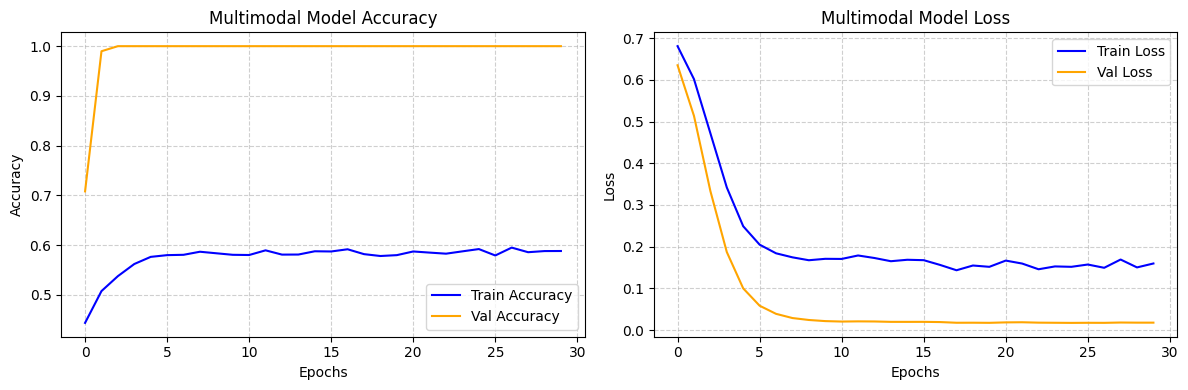

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
plt.title('Multimodal Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss',   color='orange')
plt.title('Multimodal Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
def evaluate_on_test(model, df):
    patient_preds = []
    patient_true = []

    for patient in df['Patient_ID'].unique():
        patient_data = df[df['Patient_ID'] == patient]

        preds = []
        labels = []

        for _, row in patient_data.iterrows():
            img = img_to_array(load_img(row['image_path'], target_size=(224,224))) / 255.0
            tab = row[features].values.astype(np.float32)

            pred = model.predict(
                [np.expand_dims(img,0), np.expand_dims(tab,0)],
                verbose=0
            )

            preds.append(pred[0][0])
            labels.append(row['Diagnosis'])

        final_pred = int(np.mean(preds) > 0.5)
        true_label = int(np.mean(labels) > 0.5)

        patient_preds.append(final_pred)
        patient_true.append(true_label)

    print("\n--- PATIENT LEVEL RESULTS ---")
    print(classification_report(patient_true, patient_preds))


--- FINAL TEST RESULTS (UNSEEN DATA) ---
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       509
    Leukemia       1.00      1.00      1.00      1091

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



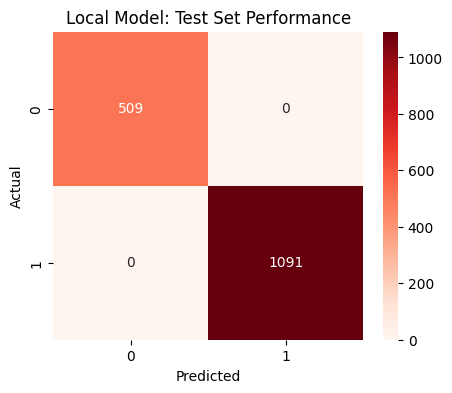

In [ ]:
evaluate_on_test(local_model, test_df)

### Connecting to Global Model

In [ ]:
SERVER_URL = "PASTE_YOUR_PUBLIC_URL_HERE"

CLEAN_URL = SERVER_URL.replace("https://", "").strip("/")

print(f"Dialing Global Server at: {CLEAN_URL}...")

fl.client.start_numpy_client(
    server_address=CLEAN_URL,
    client=LeukemiaClient(local_model, train_gen, val_gen)
)

WARNING flwr 2026-03-30 12:11:23,841 | logger.py:118 | 
        DEPRECATED FEATURE: flwr.client.start_numpy_client() is deprecated. 
	Instead, use `flwr.client.start_client()` by ensuring you first call the `.to_client()` method as shown below: 
	flwr.client.start_client(
		server_address='<IP>:<PORT>',
		client=FlowerClient().to_client(), # <-- where FlowerClient is of type flwr.client.NumPyClient object
	)
	Using `start_numpy_client()` is deprecated.

        This is a deprecated feature. It will be removed
        entirely in future versions of Flower.
        
        DEPRECATED FEATURE: flwr.client.start_numpy_client() is deprecated. 
	Instead, use `flwr.client.start_client()` by ensuring you first call the `.to_client()` method as shown below: 
	flwr.client.start_client(
		server_address='<IP>:<PORT>',
		client=FlowerClient().to_client(), # <-- where FlowerClient is of type flwr.client.NumPyClient object
	)
	Using `start_numpy_client()` is deprecated.

        This is a deprecate

Dialing Global Server at: PASTE_YOUR_PUBLIC_URL_HERE...


SystemExit: Server address (PASTE_YOUR_PUBLIC_URL_HERE) cannot be parsed.